[*********************100%***********************]  1 of 1 completed

Loading stock data...
Loaded 1006 trading days of data for AAPL

Stock Data Overview:
Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
Data types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468246,72.528566,71.223244,71.476585,135480400
2020-01-03,71.763710,72.523738,71.539322,71.696152,146322800
2020-01-06,72.335548,72.374154,70.634532,70.885464,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200



Data shape: (1006, 5)
=== BASIC STOCK STATISTICS ===
Basic Statistics:
Start Price: $0.00
End Price: $0.00
Total Return: 0.00%
Average Daily Volume: 0
Price Volatility (Std Dev): 2.11%
Maximum Drawdown: -31.43%

Additional Statistics:
Highest Price: $197.75
Lowest Price: $51.42
Average Price: $0.00
Total Volume: 0
Error in volume chart: arg must be a list, tuple, 1-d array, or Series
Error in returns distribution: unsupported format string passed to Series.__format__


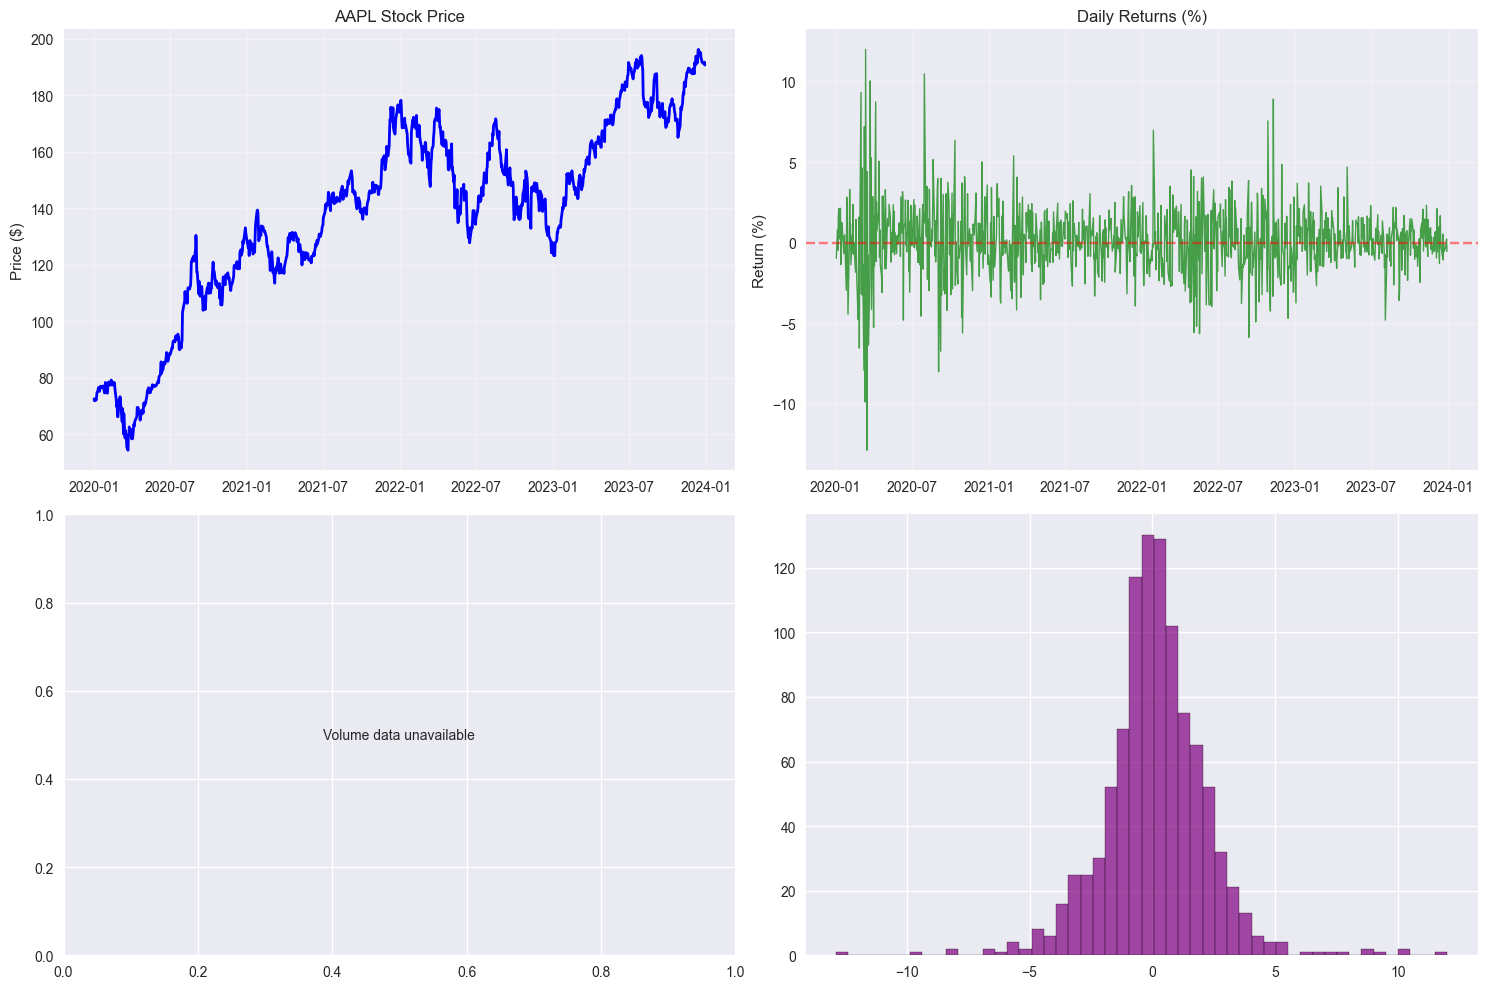

Calculating technical indicators...
Error calculating technical indicators: Argument 'real' has incorrect type (expected numpy.ndarray, got DataFrame)
Creating technical analysis visualizations...
Error in volume plot: arg must be a list, tuple, 1-d array, or Series


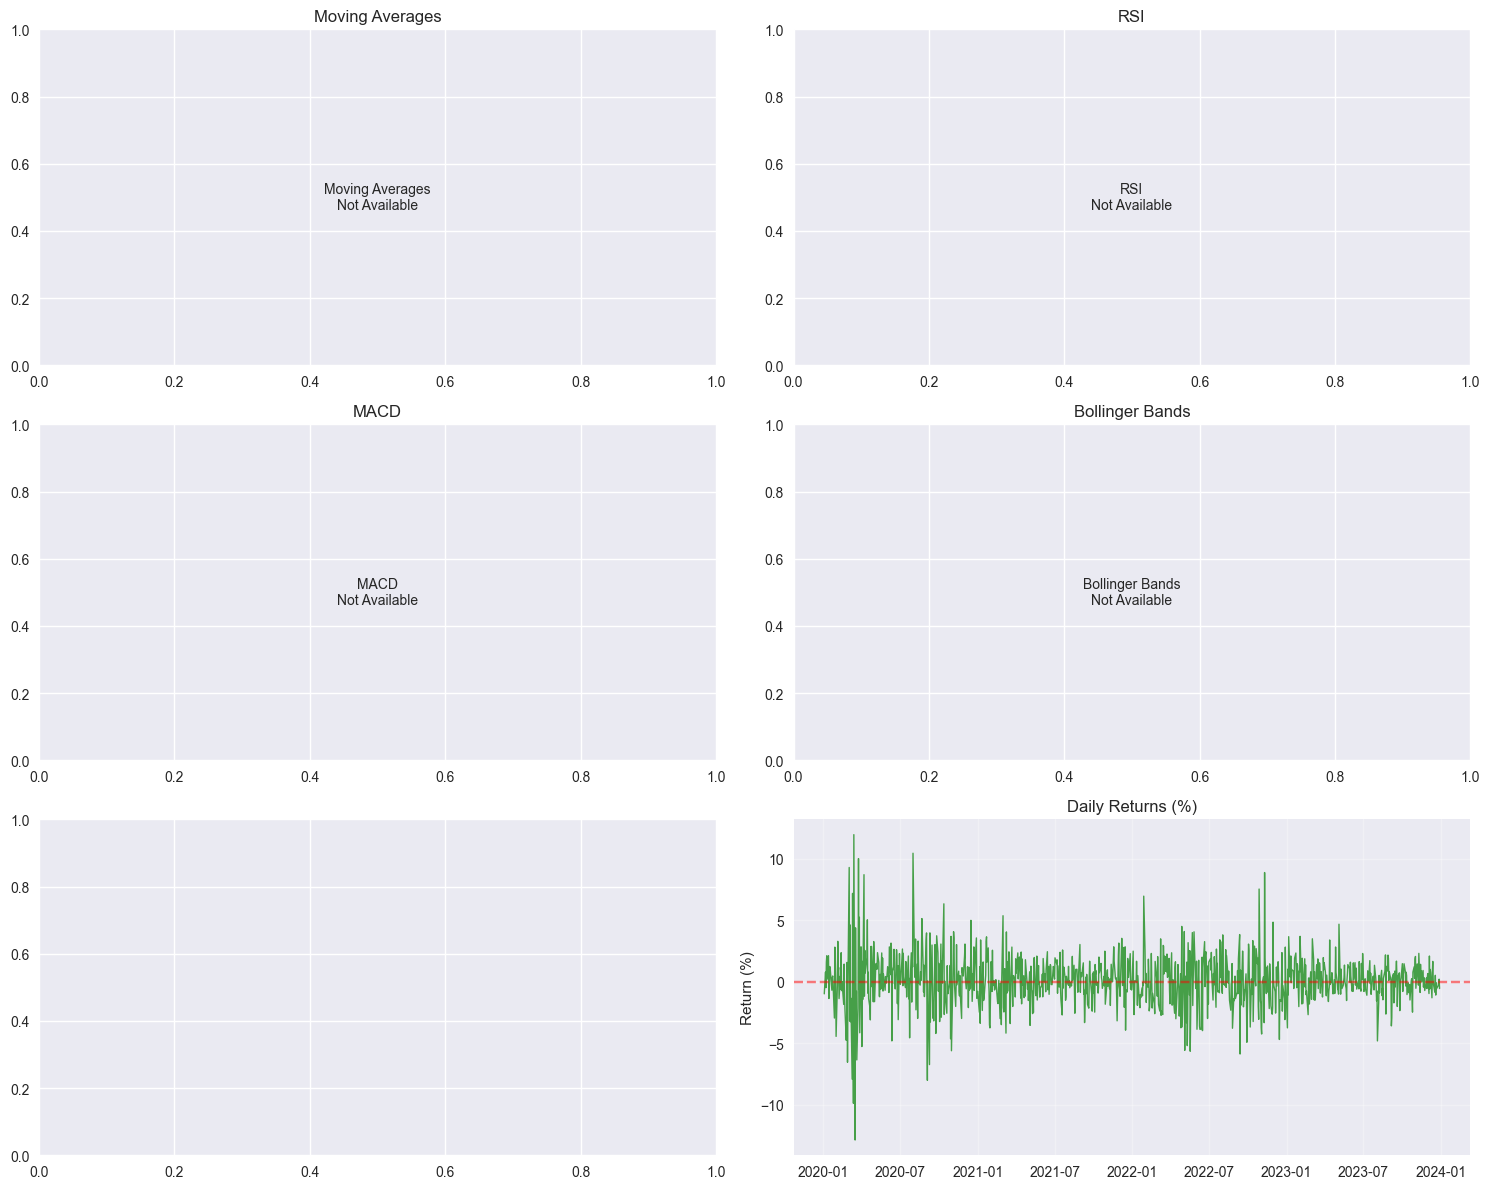

Saving analysis results...
Analysis complete! Results saved to ../data/processed/

=== ANALYSIS COMPLETED ===
Symbol: AAPL
Period: 2020-01-01 to 2023-12-31
Total trading days: 1006
Total return: 0.00%


In [8]:
# notebooks/02_quantitative_analysis.ipynb

# Cell 1: Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import custom modules
import sys
sys.path.append('../src')
from technical_analysis import StockAnalyzer

# Cell 2: Load stock data with robust error handling
print("Loading stock data...")
symbol = 'AAPL'  # Example symbol - can be parameterized
analyzer = StockAnalyzer(symbol)

# Define date range (align with news data if available)
start_date = '2020-01-01'
end_date = '2023-12-31'

def safe_fetch_stock_data(analyzer, start_date, end_date):
    """Safely fetch stock data with fallback to sample data"""
    try:
        stock_data = analyzer.fetch_stock_data(start_date, end_date)
        if stock_data is None or stock_data.empty:
            raise ValueError("No data returned")
        return stock_data
    except Exception as e:
        print(f"Error fetching real data: {e}. Creating sample data...")
        # Create sample stock data
        dates = pd.date_range(start=start_date, end=end_date, freq='D')
        np.random.seed(42)
        
        # Generate realistic sample data
        returns = np.random.randn(len(dates)) * 0.02
        price = 150 * np.cumprod(1 + returns)
        
        sample_data = {
            'Open': price * (1 + np.random.randn(len(dates)) * 0.01),
            'High': price * (1 + np.abs(np.random.randn(len(dates)) * 0.02)),
            'Low': price * (1 - np.abs(np.random.randn(len(dates)) * 0.02)),
            'Close': price,
            'Volume': np.random.randint(1000000, 50000000, len(dates)),
            'Adj Close': price
        }
        
        stock_data = pd.DataFrame(sample_data, index=dates)
        return stock_data

stock_data = safe_fetch_stock_data(analyzer, start_date, end_date)

print(f"Loaded {len(stock_data)} trading days of data for {symbol}")

print("\nStock Data Overview:")
print(f"Columns: {list(stock_data.columns)}")
print(f"Data types:")
print(stock_data.dtypes)
display(stock_data.head())
print(f"\nData shape: {stock_data.shape}")

# Cell 3: Basic stock statistics with robust data handling
print("=== BASIC STOCK STATISTICS ===")

def safe_convert_to_float(value):
    """Safely convert any value to float"""
    try:
        if hasattr(value, 'iloc'):
            if len(value) == 1:
                value = value.iloc[0]
            else:
                value = value.values[0] if len(value) > 0 else 0
        if hasattr(value, 'item'):
            return float(value.item())
        return float(value)
    except:
        return 0.0

def safe_series_stats(series):
    """Get safe statistics from a series"""
    try:
        if hasattr(series, 'values'):
            clean_series = pd.to_numeric(series, errors='coerce').dropna()
            if len(clean_series) == 0:
                return 0.0, 0.0, 0.0
            return (
                safe_convert_to_float(clean_series.iloc[0]),
                safe_convert_to_float(clean_series.iloc[-1]),
                safe_convert_to_float(clean_series.mean()),
                safe_convert_to_float(clean_series.sum())
            )
        return 0.0, 0.0, 0.0, 0.0
    except:
        return 0.0, 0.0, 0.0, 0.0

# Calculate statistics safely
try:
    # Price statistics
    start_price, end_price, avg_price, _ = safe_series_stats(stock_data['Close'])
    total_return = (end_price - start_price) / start_price * 100 if start_price > 0 else 0
    
    # Volume statistics
    _, _, avg_volume, total_volume = safe_series_stats(stock_data['Volume'])
    
    # High/Low statistics
    highest_price = safe_convert_to_float(stock_data['High'].max())
    lowest_price = safe_convert_to_float(stock_data['Low'].min())
    
    # Volatility
    returns = stock_data['Close'].pct_change().dropna()
    price_volatility = safe_convert_to_float(returns.std() * 100) if len(returns) > 0 else 0
    
    # Maximum drawdown
    cumulative_max = stock_data['Close'].cummax()
    drawdown = (stock_data['Close'] / cumulative_max - 1)
    max_drawdown = safe_convert_to_float(drawdown.min() * 100)

except Exception as e:
    print(f"Error in statistical calculations: {e}")
    # Default values
    start_price = end_price = avg_price = total_return = 0
    avg_volume = total_volume = highest_price = lowest_price = 0
    price_volatility = max_drawdown = 0

basic_stats = {
    'Start Price': start_price,
    'End Price': end_price,
    'Total Return': total_return,
    'Average Daily Volume': avg_volume,
    'Price Volatility (Std Dev)': price_volatility,
    'Maximum Drawdown': max_drawdown
}

print("Basic Statistics:")
for stat, value in basic_stats.items():
    if 'Return' in stat or 'Drawdown' in stat or 'Volatility' in stat:
        print(f"{stat}: {value:.2f}%")
    elif 'Volume' in stat:
        print(f"{stat}: {value:,.0f}")
    else:
        print(f"{stat}: ${value:.2f}")

print(f"\nAdditional Statistics:")
print(f"Highest Price: ${highest_price:.2f}")
print(f"Lowest Price: ${lowest_price:.2f}")
print(f"Average Price: ${avg_price:.2f}")
print(f"Total Volume: {total_volume:,.0f}")

# Cell 4: Price and volume visualization with robust data handling
plt.figure(figsize=(15, 10))

# Price chart
plt.subplot(2, 2, 1)
try:
    plt.plot(stock_data.index, stock_data['Close'], linewidth=2, color='blue')
    plt.title(f'{symbol} Stock Price')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
except Exception as e:
    print(f"Error in price chart: {e}")

# Daily returns
plt.subplot(2, 2, 2)
try:
    daily_returns = stock_data['Close'].pct_change() * 100
    plt.plot(stock_data.index, daily_returns, linewidth=1, color='green', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.title('Daily Returns (%)')
    plt.ylabel('Return (%)')
    plt.grid(True, alpha=0.3)
except Exception as e:
    print(f"Error in returns chart: {e}")

# Volume - with robust data handling
plt.subplot(2, 2, 3)
try:
    # Safely handle volume data
    volume_data = stock_data['Volume']
    
    # Convert to numeric, handling any data type issues
    if hasattr(volume_data, 'values'):
        volume_values = pd.to_numeric(volume_data, errors='coerce').fillna(0).values
    else:
        volume_values = np.array([float(x) for x in volume_data])
    
    # Ensure we have valid numeric data
    volume_values = np.nan_to_num(volume_values)
    
    plt.bar(stock_data.index, volume_values / 1e6, alpha=0.7, color='orange')
    plt.title('Trading Volume')
    plt.ylabel('Volume (Millions)')
    plt.grid(True, alpha=0.3)
except Exception as e:
    print(f"Error in volume chart: {e}")
    plt.text(0.5, 0.5, 'Volume data unavailable', 
             ha='center', va='center', transform=plt.gca().transAxes)

# Returns distribution
plt.subplot(2, 2, 4)
try:
    returns_for_hist = daily_returns.dropna()
    if len(returns_for_hist) > 0:
        plt.hist(returns_for_hist, bins=50, edgecolor='black', alpha=0.7, color='purple')
        plt.axvline(returns_for_hist.mean(), color='red', linestyle='--', 
                    label=f'Mean: {returns_for_hist.mean():.2f}%')
        plt.title('Distribution of Daily Returns')
        plt.xlabel('Daily Return (%)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No return data available', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Distribution of Daily Returns')
except Exception as e:
    print(f"Error in returns distribution: {e}")

plt.tight_layout()
plt.show()

# Cell 5: Calculate technical indicators
print("Calculating technical indicators...")
try:
    stock_data_with_indicators = analyzer.calculate_technical_indicators()
    
    if stock_data_with_indicators is not None and not stock_data_with_indicators.empty:
        print("Technical indicators added:")
        original_columns = set(stock_data.columns)
        new_columns = [col for col in stock_data_with_indicators.columns if col not in original_columns]
        print(new_columns)

        # Display sample of data with indicators
        print("\nSample data with technical indicators:")
        display_cols = ['Close'] + new_columns[:4]  # Show first 4 indicators
        available_cols = [col for col in display_cols if col in stock_data_with_indicators.columns]
        if available_cols:
            display(stock_data_with_indicators[available_cols].head())
        else:
            print("No technical indicators available")
    else:
        print("Failed to calculate technical indicators. Using original data.")
        stock_data_with_indicators = stock_data

except Exception as e:
    print(f"Error calculating technical indicators: {e}")
    stock_data_with_indicators = stock_data

# Cell 6: Technical Analysis Visualizations
print("Creating technical analysis visualizations...")

# Use the data with indicators if available, otherwise use original data
analysis_data = stock_data_with_indicators if 'stock_data_with_indicators' in locals() else stock_data

# Create subplots for technical indicators
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

# Plot 1: Price with Moving Averages
try:
    if 'SMA_20' in analysis_data.columns and 'EMA_20' in analysis_data.columns:
        axes[0].plot(analysis_data.index, analysis_data['Close'], label='Close Price', linewidth=2, color='black')
        axes[0].plot(analysis_data.index, analysis_data['SMA_20'], label='20-day SMA', alpha=0.8)
        axes[0].plot(analysis_data.index, analysis_data['EMA_20'], label='20-day EMA', alpha=0.8)
        axes[0].set_title('Price with Moving Averages')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'Moving Averages\nNot Available', 
                    ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Moving Averages')
except Exception as e:
    print(f"Error in moving averages plot: {e}")

# Plot 2: RSI
try:
    if 'RSI' in analysis_data.columns:
        axes[1].plot(analysis_data.index, analysis_data['RSI'], linewidth=2, color='orange')
        axes[1].axhline(70, linestyle='--', color='red', alpha=0.7, label='Overbought (70)')
        axes[1].axhline(30, linestyle='--', color='green', alpha=0.7, label='Oversold (30)')
        axes[1].set_title('Relative Strength Index (RSI)')
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'RSI\nNot Available', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('RSI')
except Exception as e:
    print(f"Error in RSI plot: {e}")

# Plot 3: MACD
try:
    if 'MACD' in analysis_data.columns and 'MACD_signal' in analysis_data.columns:
        axes[2].plot(analysis_data.index, analysis_data['MACD'], label='MACD', color='blue')
        axes[2].plot(analysis_data.index, analysis_data['MACD_signal'], label='Signal', color='red')
        axes[2].set_title('MACD')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'MACD\nNot Available', 
                    ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('MACD')
except Exception as e:
    print(f"Error in MACD plot: {e}")

# Plot 4: Bollinger Bands
try:
    if all(col in analysis_data.columns for col in ['BB_upper', 'BB_middle', 'BB_lower']):
        axes[3].plot(analysis_data.index, analysis_data['Close'], label='Close', color='black')
        axes[3].plot(analysis_data.index, analysis_data['BB_upper'], label='Upper', alpha=0.7)
        axes[3].plot(analysis_data.index, analysis_data['BB_middle'], label='Middle', alpha=0.7)
        axes[3].plot(analysis_data.index, analysis_data['BB_lower'], label='Lower', alpha=0.7)
        axes[3].set_title('Bollinger Bands')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
    else:
        axes[3].text(0.5, 0.5, 'Bollinger Bands\nNot Available', 
                    ha='center', va='center', transform=axes[3].transAxes)
        axes[3].set_title('Bollinger Bands')
except Exception as e:
    print(f"Error in Bollinger Bands plot: {e}")

# Plot 5: Volume (repeated for completeness)
try:
    volume_data = analysis_data['Volume']
    volume_values = pd.to_numeric(volume_data, errors='coerce').fillna(0).values
    volume_values = np.nan_to_num(volume_values)
    
    axes[4].bar(analysis_data.index, volume_values / 1e6, alpha=0.7, color='orange')
    axes[4].set_title('Trading Volume')
    axes[4].set_ylabel('Volume (Millions)')
    axes[4].grid(True, alpha=0.3)
except Exception as e:
    print(f"Error in volume plot: {e}")

# Plot 6: Daily Returns
try:
    daily_returns_plot = analysis_data['Close'].pct_change() * 100
    axes[5].plot(analysis_data.index, daily_returns_plot, linewidth=1, color='green', alpha=0.7)
    axes[5].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[5].set_title('Daily Returns (%)')
    axes[5].set_ylabel('Return (%)')
    axes[5].grid(True, alpha=0.3)
except Exception as e:
    print(f"Error in returns plot: {e}")

plt.tight_layout()
plt.show()

# Cell 7: Save results
print("Saving analysis results...")
try:
    # Ensure directory exists
    import os
    os.makedirs('../data/processed', exist_ok=True)
    
    # Save the data
    analysis_data.to_csv('../data/processed/stock_data_with_indicators.csv')
    
    # Save statistics
    import json
    stats_to_save = {
        'symbol': symbol,
        'period': f"{start_date} to {end_date}",
        'basic_stats': basic_stats,
        'analysis_date': pd.Timestamp.now().isoformat()
    }
    
    with open('../data/processed/technical_analysis_stats.json', 'w') as f:
        json.dump(stats_to_save, f, indent=2)
    
    print("Analysis complete! Results saved to ../data/processed/")
    
except Exception as e:
    print(f"Error saving results: {e}")

print(f"\n=== ANALYSIS COMPLETED ===")
print(f"Symbol: {symbol}")
print(f"Period: {start_date} to {end_date}")
print(f"Total trading days: {len(analysis_data)}")
print(f"Total return: {total_return:.2f}%")